In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import html
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV
from nltk.stem import SnowballStemmer

# Configurazione grafici
sns.set_theme(style="whitegrid")
%matplotlib inline

In [13]:
def to_1d(x):
    if hasattr(x, 'values'): # Controlla se è un DataFrame/Series pandas
        return x.values.reshape(-1)
    return x.reshape(-1)

In [3]:
TRAIN_FILE = 'winter_project_2026/development.csv'   
EVAL_FILE = 'winter_project_2026/evaluation.csv'
OUTPUT_FILE = 'winter_project_2026/sample_submission.csv'

dev_df = pd.read_csv(TRAIN_FILE)
eval_df = pd.read_csv(EVAL_FILE)

dev_df.head()

,Id,source,title,article,page_rank,timestamp,label
0,0,AllAfrica.com,OPEC Boosts Nigeria&#39;s Oil Revenue By .82m Bpd,THE Organisation of Petroleum Exporting Countr...,5,2004-09-16 22:39:53,5
1,1,Xinhua,Yearender: Mideast peace roadmap reaches dead-...,Looking back at the major events that took pla...,5,2004-12-17 19:01:14,0
2,2,Yahoo,Battleground Dispatches for Oct. 5 \\n (CQP...,CQPolitics.com - Here are today's Battleground...,5,2006-10-05 18:42:29,0
3,3,BBC,Air best to resuscitate newborns,Air rather than oxygen should be used to resus...,5,0000-00-00 00:00:00,0
4,4,Yahoo,High tech German train crash kills at least on...,"<p><a href=""http://us.rd.yahoo.com/dailynews/r...",5,2006-09-22 17:28:57,0


In [4]:
dev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79997 entries, 0 to 79996
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         79997 non-null  int64 
 1   source     79997 non-null  object
 2   title      79996 non-null  object
 3   article    79996 non-null  object
 4   page_rank  79997 non-null  int64 
 5   timestamp  79997 non-null  object
 6   label      79997 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 4.3+ MB


In [5]:
dev_df.isna().any()

Id           False
source       False
title         True
article       True
page_rank    False
timestamp    False
label        False
dtype: bool

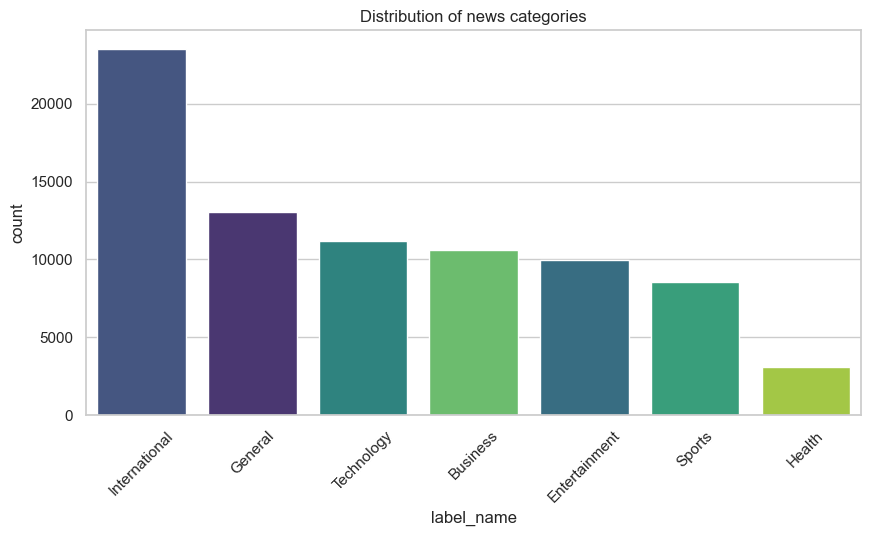

label
0    0.294286
5    0.163169
2    0.139518
1    0.132355
3    0.124717
4    0.107179
6    0.038776
Name: proportion, dtype: float64


In [6]:
# Labels' mapping  
label_map = {
    0: 'International', 1: 'Business', 2: 'Technology', 
    3: 'Entertainment', 4: 'Sports', 5: 'General', 6: 'Health'
}

dev_df['label_name'] = dev_df['label'].map(label_map)

plt.figure(figsize=(10, 5))
sns.countplot(x='label_name', data=dev_df, order=dev_df['label_name'].value_counts().index, palette='viridis', hue='label_name', legend=False)
plt.title("Distribution of news categories")
plt.xticks(rotation=45)
plt.show()

print(dev_df['label'].value_counts(normalize=True))

In [ ]:
# gestione testo + rimozione feature che non usiamo
def preprocess_text(df, remove_duplicates=False):
    if remove_duplicates: 
        df = df.drop_duplicates(subset=['title', 'article'], keep='first').copy().reset_index(drop=True) # .reset_index(drop=True)
    else:
        df = df.copy()
        
    # Feature Weighting: Ripetiamo la fonte 3 volte per darle più peso nel TF-IDF
    source_feature = (df['source'].fillna('') + " ") * 3
    df['text_combined'] = source_feature + df['title'].fillna('') + " " + df['article'].fillna('')
    
    stemmer = SnowballStemmer("english")
    
    def clean(text):
        text = str(text).lower()
        text = html.unescape(text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'[^a-z0-9\s$€%£]', ' ', text)  # useful symbols for class=business (€,%,$)           
        text = re.sub(r'\s+', ' ', text).strip()
        return " ".join([stemmer.stem(word) for word in text.split()])

    df['clean_text'] = df['text_combined'].apply(clean)
    return df

def extract_time_features(df):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['hour'] = df['timestamp'].dt.hour.fillna(0)
    df['day_of_week'] = df['timestamp'].dt.dayofweek.fillna(0)
    return df

dev_df = extract_time_features(dev_df)
eval_df = extract_time_features(eval_df)  # controlla se va fatto

dev_df = preprocess_text(dev_df, remove_duplicates=True)
eval_df = preprocess_text(eval_df, remove_duplicates=False) # controlla se va fatto

In [ ]:
# DEFINIZIONE DEL PREPROCESSING TESTO E FEATURE (non ancora applicato)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import FunctionTransformer

# Pipeline specifica per il testo: TF-IDF -> Feature Selection
text_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='')),
    ('flatten', FunctionTransformer(to_1d, accept_sparse=False)),
    ('tfidf', TfidfVectorizer(stop_words='english', min_df=3, sublinear_tf=True))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('scaler', StandardScaler())
])

# Preprocessor generale
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, ['clean_text']),
        ('ohe', cat_pipeline, ['source']),
        ('num', num_pipeline, ['page_rank', 'hour', 'day_of_week'])
    ], 
    remainder='drop'
)

In [ ]:
base_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, dual='auto'))
])

# Definizione Feature e Target
X = dev_df[['clean_text', 'source', 'page_rank', 'hour', 'day_of_week']]
y = dev_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

PARAM_GRID = {
    # Parametri TF-IDF (dentro text -> tfidf)
    'preprocessor__text__tfidf__ngram_range': [(1, 2)],
    'preprocessor__text__tfidf__max_features': [None],
    # Parametri SVC
    'clf__C': [0.1, 0.2] 
}

grid = GridSearchCV(
    base_pipeline, 
    PARAM_GRID, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=1
)

""" 
La Grid Search "pesante" la facciamo una volta sola per trovare la migliore rappresentazione dei dati (testo) e settare il primo modello. Gli altri modelli si "innestano" su questa base solida per dare stabilità al voto finale, senza bisogno di essere ottimizzati ossessivamente da zero.
"""

grid.fit(X_train, y_train)

best_params = grid.best_params_
print(f"Migliori parametri: {best_params}")
print(f"Miglior CV F1 Score: {grid.best_score_:.4f}")

# Validazione rapida sul set di hold-out
best_model_val = grid.best_estimator_
y_pred_val = best_model_val.predict(X_val)
print(f"\nReport Validazione (Split 20%):")
print(classification_report(y_val, y_pred_val))

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Migliori parametri: {'clf__C': 0.2, 'preprocessor__text__selector__k': 'all', 'preprocessor__text__tfidf__max_features': None, 'preprocessor__text__tfidf__ngram_range': (1, 2)}

Report Validazione (Split 20%):
              precision    recall  f1-score   support

           0       0.75      0.74      0.75      4569
           1       0.74      0.83      0.78      2068
           2       0.81      0.82      0.82      2175
           3       0.63      0.53      0.58      1878
           4       0.81      0.94      0.87      1688
           5       0.60      0.49      0.54      2445
           6       0.54      0.82      0.65       586

    accuracy                           0.72     15409
   macro avg       0.70      0.74      0.71     15409
weighted avg       0.72      0.72      0.72     15409



In [10]:
pd.DataFrame(dev_df).isna().any()

Id               False
source           False
title             True
article           True
page_rank        False
timestamp         True
label            False
label_name       False
hour              True
day_of_week       True
text_combined    False
clean_text       False
dtype: bool

In [ ]:
svc = CalibratedClassifierCV(
    LinearSVC(C=best_params['clf__C'], class_weight='balanced', random_state=42, dual='auto'),
    method='sigmoid', cv=3
)

# Logistic Regression
lr = LogisticRegression(C=best_params['clf__C'], class_weight='balanced', solver='liblinear', random_state=42)

# SGD Classifier
sgd = SGDClassifier(alpha=1e-4, class_weight='balanced', loss='modified_huber', random_state=42)

# VOTING CLASSIFIER
voting_clf = VotingClassifier(
    estimators=[('svc', svc), ('lr', lr), ('sgd', sgd)],
    voting='soft', n_jobs=-1
)

text_pipeline_final = Pipeline([
    ('flatten', FunctionTransformer(to_1d, accept_sparse=False)),
    ('tfidf', TfidfVectorizer(stop_words='english', min_df=3, sublinear_tf=True, 
                              ngram_range=best_params['preprocessor__text__tfidf__ngram_range'])),
])

# final_pipeline = Pipeline([
#     ('preprocessor', ColumnTransformer([
#         ('text', text_pipeline_final, 'clean_text'),
#         ('ohe', OneHotEncoder(handle_unknown='ignore'), ['source']),
#         ('num', StandardScaler(), ['page_rank', 'hour', 'day_of_week'])
#     ])),
#     ('clf', voting_clf)
# ])

final_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('text', text_pipeline_final, ['clean_text']),
        ('ohe', cat_pipeline, ['source']),
        ('num', num_pipeline, ['page_rank', 'hour', 'day_of_week'])
    ])),
    ('clf', voting_clf)
])

final_pipeline.fit(X_train, y_train)
y_pred_val = final_pipeline.predict(X_val)
print("\n--- Report Validazione (Ensemble Bilanciato) ---")
print(classification_report(y_val, y_pred_val))


--- Report Validazione (Ensemble Bilanciato) ---
              precision    recall  f1-score   support

           0       0.73      0.77      0.75      4569
           1       0.74      0.82      0.78      2068
           2       0.83      0.80      0.82      2175
           3       0.63      0.51      0.57      1878
           4       0.82      0.93      0.87      1688
           5       0.58      0.48      0.53      2445
           6       0.58      0.76      0.66       586

    accuracy                           0.72     15409
   macro avg       0.70      0.73      0.71     15409
weighted avg       0.72      0.72      0.72     15409



In [15]:
print("Riaddestramento su TUTTO il dataset di sviluppo...")
final_pipeline.fit(X, y) 
print("Generazione predizioni finali...")
y_pred_eval = final_pipeline.predict(eval_df)

submission = pd.DataFrame({'Id': np.arange(len(y_pred_eval)), 'Predicted': y_pred_eval})
submission.to_csv(OUTPUT_FILE, index=False)
print(f"File salvato: {OUTPUT_FILE}")

Riaddestramento su TUTTO il dataset di sviluppo...
Generazione predizioni finali...
File salvato: winter_project_2026/sample_submission.csv


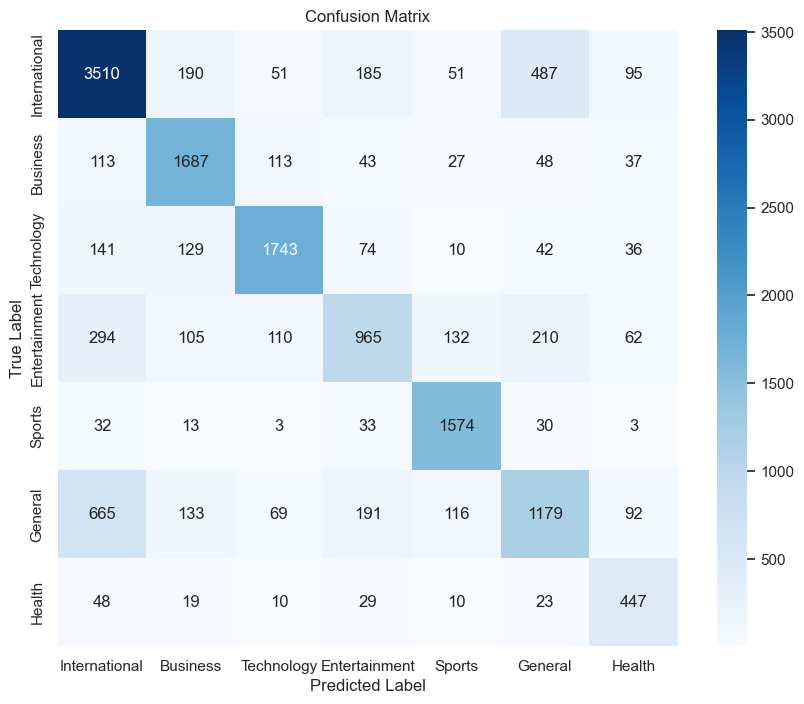


📊 Analisi per Classe:
Classe 0 (International): 4569 samples, Accuracy=0.77
  → Confusa principalmente con: {5: 487, 1: 190}
Classe 1 (Business): 2068 samples, Accuracy=0.82
  → Confusa principalmente con: {2: 113, 0: 113}
Classe 2 (Technology): 2175 samples, Accuracy=0.80
  → Confusa principalmente con: {0: 141, 1: 129}
Classe 3 (Entertainment): 1878 samples, Accuracy=0.51
  → Confusa principalmente con: {0: 294, 5: 210}
Classe 4 (Sports): 1688 samples, Accuracy=0.93
  → Confusa principalmente con: {3: 33, 0: 32}
Classe 5 (General): 2445 samples, Accuracy=0.48
  → Confusa principalmente con: {0: 665, 3: 191}
Classe 6 (Health): 586 samples, Accuracy=0.76
  → Confusa principalmente con: {0: 48, 3: 29}


In [17]:
from sklearn.metrics import confusion_matrix

# Dopo aver fatto le predizioni di validazione
cm = confusion_matrix(y_val, y_pred_val)

# Visualizza confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_map.values(), 
            yticklabels=label_map.values())
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Analisi per classe
print("\n📊 Analisi per Classe:")
for label in range(7):
    mask = (y_val == label)
    n_samples = mask.sum()
    n_correct = (y_val[mask] == y_pred_val[mask]).sum()
    accuracy = n_correct / n_samples if n_samples > 0 else 0
    
    # Dove sbagliano le predizioni?
    wrong_preds = y_pred_val[mask & (y_val != y_pred_val)]
    if len(wrong_preds) > 0:
        most_confused_with = pd.Series(wrong_preds).value_counts().head(2)
        print(f"Classe {label} ({label_map[label]}): {n_samples} samples, Accuracy={accuracy:.2f}")
        print(f"  → Confusa principalmente con: {most_confused_with.to_dict()}")
